In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!ls /content/drive/MyDrive

 1000020104_Vrishti_Rajput_NG_01.gdoc	     'Graded Lab-2-Qs-B-P1.gdoc'
 A2_ToC_EVEN2026_Vrishti_Rajput.gdoc	      IMG_8258.HEIC
 Aadhaar.PNG				      IMG_8259.HEIC
'assignment 0.gdoc'			     'Mini Project.gdoc'
 Assignment.gdoc			      NGL-2_Assignment.gdoc
'Colab Notebooks'			      note_copy.pdf
'Copy of IMG_20260323_173126.dng'	      Photos
 CSN301_NGL1_Vrishti_Rajput_1000020104.gdoc   Resume.png
 datasets				     'Software Engineering Unit 1.gdoc'
'DSA roadmap.gdoc'			     'Untitled document (1).gdoc'
'Exp 3.gdoc'				     'Untitled document (2).gdoc'
'Google AI Studio'			     'Untitled document (3).gdoc'
'Graded Lab-1-B-P1.gdoc'		     'Untitled document.gdoc'


In [4]:
!find /content/drive/MyDrive -name "kagglecatsanddogs_5340.zip"

/content/drive/MyDrive/datasets/kagglecatsanddogs_5340.zip


In [5]:
import zipfile

zip_path = "/content/drive/MyDrive/datasets/kagglecatsanddogs_5340.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Extraction complete!")

Extraction complete!


In [6]:
!ls /content/dataset

 CDLA-Permissive-2.0.pdf   PetImages  'readme[1].txt'


In [7]:
!ls /content/dataset/PetImages

Cat  Dog


In [8]:
!ls /content/dataset/PetImages/Cat | wc -l
!ls /content/dataset/PetImages/Dog | wc -l

12501
12501


In [9]:
import cv2
import numpy as np
import os

data = []
labels = []

IMG_SIZE = 64

cat_path = "/content/dataset/PetImages/Cat"
dog_path = "/content/dataset/PetImages/Dog"

In [10]:
count = 0

for img in os.listdir(cat_path):
    if count >= 500:
        break

    try:
        image = cv2.imread(os.path.join(cat_path, img))

        if image is None:
            continue

        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

        data.append(image.flatten())
        labels.append(0)

        count += 1

    except:
        pass

print("Cats loaded:", count)

Cats loaded: 500


In [11]:
count = 0

for img in os.listdir(dog_path):
    if count >= 500:
        break

    try:
        image = cv2.imread(os.path.join(dog_path, img))

        if image is None:
            continue

        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

        data.append(image.flatten())
        labels.append(1)

        count += 1

    except:
        pass

print("Dogs loaded:", count)

Dogs loaded: 500


In [12]:
X = np.array(data)
y = np.array(labels)

print(X.shape)
print(y.shape)

(1000, 12288)
(1000,)


In [13]:
print(X.shape)
print(y.shape)

(1000, 12288)
(1000,)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(800, 12288)
(200, 12288)


In [15]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [16]:
from sklearn.svm import SVC

svm = SVC(kernel='linear')

svm.fit(X_train, y_train)

print("Training Complete!")

Training Complete!


In [17]:
y_pred = svm.predict(X_test)

In [18]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.52


In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.50      0.53      0.52        96
           1       0.54      0.51      0.52       104

    accuracy                           0.52       200
   macro avg       0.52      0.52      0.52       200
weighted avg       0.52      0.52      0.52       200



Prediction: Cat


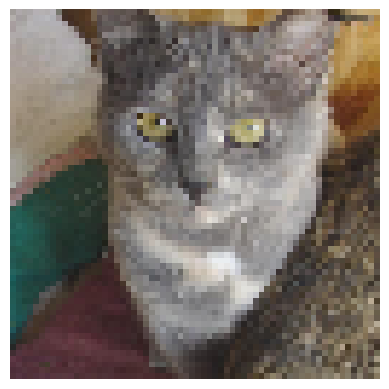

In [20]:
import matplotlib.pyplot as plt
import random

img_name = random.choice(os.listdir(cat_path))

img = cv2.imread(os.path.join(cat_path, img_name))
img = cv2.resize(img, (64,64))

sample = img.flatten().reshape(1,-1)/255.0

prediction = svm.predict(sample)

print("Prediction:", "Cat" if prediction[0]==0 else "Dog")

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [24]:
import joblib

joblib.dump(svm, "cats_dogs_svm.pkl")

['cats_dogs_svm.pkl']

In [25]:
from google.colab import files

files.download("cats_dogs_svm.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

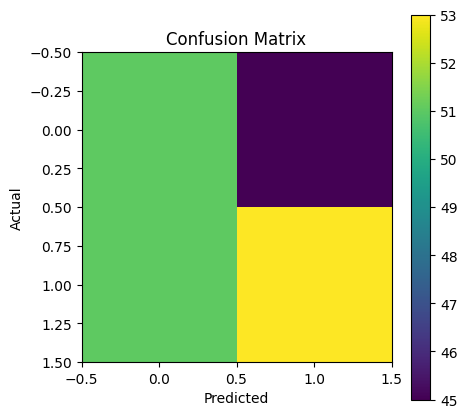

In [26]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,5))
plt.imshow(cm)
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()